# Nettoyage et Feature Engineering

Objectif: creer un script propre et reproductible pour nettoyer le dataset, traiter les valeurs manquantes, gerer les outliers, encoder les variables categorielles et produire des jeux train/val/test.

Dataset attendu: `backend/dataset_ProjetML_2026.csv`

Notes:
- Les colonnes cibles sont `Categorie` (classification) et `Prix_Revente` (regression).
- Le notebook propose plusieurs strategies d'imputation a comparer.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer, KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)

DATA_PATH = Path("..") / "backend" / "dataset_ProjetML_2026.csv"
OUTPUT_DIR = Path("..") / "data" / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42


## 1. Charger les donnees brutes

Lire le fichier source, inspecter les premieres lignes et verifier les dimensions.


In [2]:
df_raw = pd.read_csv(DATA_PATH)

print("Shape:", df_raw.shape)
display(df_raw.head())

display(df_raw.info())

display(df_raw.describe(include="all"))


Shape: (10500, 9)


,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente,Categorie,Source,Rapport_Collecte
0,16.708780,70.940977,0.0,1.0,1.0,0.835439,Papier,NaN,Lot de papier récupéré dans un site non rensei...
1,47.277476,64.702925,0.0,NaN,3.0,4.727748,Plastique,Usine_A,"Lot plastique à l'Usine A. Volume 64.7 L, poid..."
2,NaN,317.415183,0.0,NaN,9.0,4.211790,Verre,Usine_B,Bris de verre ou contenants en provenance de l...
3,NaN,21.474391,0.0,NaN,1.0,0.442067,Papier,Centre_Tri,Feuilles et cartons collectés au Centre de Tri...
4,NaN,59.462176,0.0,1.0,NaN,0.723004,Papier,Usine_B,Déchet de type papier identifié à l'Usine B. V...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10500 entries, 0 to 10499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Poids             9471 non-null   float64
 1   Volume            9960 non-null   float64
 2   Conductivite      9483 non-null   float64
 3   Opacite           9465 non-null   float64
 4   Rigidite          9942 non-null   float64
 5   Prix_Revente      9964 non-null   float64
 6   Categorie         9986 non-null   object 
 7   Source            9964 non-null   object 
 8   Rapport_Collecte  10500 non-null  object 
dtypes: float64(6), object(3)
memory usage: 738.4+ KB


None

,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente,Categorie,Source,Rapport_Collecte
count,9471.000000,9960.000000,9483.000000,9465.000000,9942.000000,9964.000000,9986,9964,10500
unique,NaN,NaN,NaN,NaN,NaN,NaN,4,4,9336
top,NaN,NaN,NaN,NaN,NaN,NaN,Plastique,Collecte_Citoyenne,Ferraille ou métal collecté via la collecte ci...
freq,NaN,NaN,NaN,NaN,NaN,NaN,2795,2644,8
mean,77.796501,144.408079,0.207674,1.160388,5.886643,58.587857,NaN,NaN,NaN
std,127.847433,136.384216,0.378934,5.492723,3.087225,720.059089,NaN,NaN,NaN
min,-99.000000,-26.807712,0.000000,0.000037,1.000000,-50.000000,NaN,NaN,NaN
25%,19.751538,44.436897,0.000000,0.196410,3.000000,1.393623,NaN,NaN,NaN
50%,39.193029,88.084217,0.000000,0.553484,5.000000,4.135356,NaN,NaN,NaN
75%,130.497561,240.200023,0.000000,1.000000,9.000000,6.781634,NaN,NaN,NaN


## 2. Nettoyage des donnees (types, valeurs manquantes, doublons)

On harmonise les types, on mesure les valeurs manquantes, puis on compare plusieurs strategies d'imputation.


In [3]:
df = df_raw.copy()

# Typage explicite des colonnes numeriques
numeric_cols = [
    "Poids",
    "Volume",
    "Conductivite",
    "Opacite",
    "Rigidite",
    "Prix_Revente",
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Duplicats
dup_count = df.duplicated().sum()
print("Duplicats:", dup_count)
if dup_count > 0:
    df = df.drop_duplicates()

# Rapport de valeurs manquantes
missing_report = (
    df.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .to_frame(name="missing_pct")
)

display(missing_report)

# Comparaison des strategies d'imputation sur les features numeriques
features_num = [c for c in numeric_cols if c != "Prix_Revente"]

imputers = {
    "median": "median",
    "knn": KNNImputer(n_neighbors=5),
    "iterative": IterativeImputer(random_state=RANDOM_STATE),
}

imputed_variants = {}
for name, imp in imputers.items():
    df_tmp = df.copy()
    if name == "median":
        df_tmp[features_num] = df_tmp[features_num].fillna(df_tmp[features_num].median())
    else:
        df_tmp[features_num] = imp.fit_transform(df_tmp[features_num])
    imputed_variants[name] = df_tmp

for name, df_tmp in imputed_variants.items():
    print(name, "missing after imputation:")
    print(df_tmp[features_num].isna().sum())


Duplicats: 776


,missing_pct
Opacite,10.170712
Poids,10.016454
Conductivite,9.995886
Rigidite,5.697244
Volume,5.522419
Source,5.501851
Prix_Revente,5.481283
Categorie,5.255039
Rapport_Collecte,0.000000


median missing after imputation:
Poids           0
Volume          0
Conductivite    0
Opacite         0
Rigidite        0
dtype: int64
knn missing after imputation:
Poids           0
Volume          0
Conductivite    0
Opacite         0
Rigidite        0
dtype: int64
iterative missing after imputation:
Poids           0
Volume          0
Conductivite    0
Opacite         0
Rigidite        0
dtype: int64


c:\Users\DELL\anaconda3\envs\MesTPMachineLearning\lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


## 3. Traitement des outliers

Detection via IQR et z-score. On applique un capping pour limiter l'impact sans supprimer trop de lignes.


In [4]:
# Choisir une version impute pour la suite
# Options: "median", "knn", "iterative"
SELECTED_IMPUTATION = "median"

df_clean = imputed_variants[SELECTED_IMPUTATION].copy()

# IQR capping
for col in features_num:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

# Z-score inspection
z_scores = ((df_clean[features_num] - df_clean[features_num].mean()) / df_clean[features_num].std(ddof=0)).abs()

outlier_counts = (z_scores > 3).sum().sort_values(ascending=False)
print("Outliers by z-score > 3:")
print(outlier_counts)


Outliers by z-score > 3:
Opacite         90
Poids            0
Volume           0
Conductivite     0
Rigidite         0
dtype: int64


## 4. Encodage des variables categorielles

Encodage One-Hot pour la colonne `Source` (si presente).


In [5]:
categorical_cols = ["Source"] if "Source" in df_clean.columns else []

ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

df_encoded = df_clean.copy()
if categorical_cols:
    ohe_array = ohe.fit_transform(df_clean[categorical_cols])
    ohe_cols = ohe.get_feature_names_out(categorical_cols)
    df_ohe = pd.DataFrame(ohe_array, columns=ohe_cols, index=df_clean.index)
    df_encoded = pd.concat([df_clean.drop(columns=categorical_cols), df_ohe], axis=1)

print("Encoded shape:", df_encoded.shape)


Encoded shape: (9724, 13)


## 5. Feature engineering (aggregations, dates, interactions)

Creation de variables derivees simples et utiles pour la prediction (ratios, logs, interactions).


In [6]:
df_fe = df_encoded.copy()

# Ratios et interactions simples (eviter division par zero)
if set(["Poids", "Volume"]).issubset(df_fe.columns):
    df_fe["Densite"] = df_fe["Poids"] / df_fe["Volume"].replace(0, np.nan)

if set(["Conductivite", "Opacite"]).issubset(df_fe.columns):
    df_fe["Cond_Opacite_Ratio"] = df_fe["Conductivite"] / df_fe["Opacite"].replace(0, np.nan)

if "Volume" in df_fe.columns:
    df_fe["Log_Volume"] = np.log1p(df_fe["Volume"])

# Nettoyage des valeurs infinies creees par les ratios
for col in ["Densite", "Cond_Opacite_Ratio"]:
    if col in df_fe.columns:
        df_fe[col] = df_fe[col].replace([np.inf, -np.inf], np.nan)
        df_fe[col] = df_fe[col].fillna(df_fe[col].median())

print("Feature engineered shape:", df_fe.shape)


Feature engineered shape: (9724, 16)


c:\Users\DELL\anaconda3\envs\MesTPMachineLearning\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


## 6. Normalisation / standardisation

Application d'un scaler sur les variables numeriques pour stabiliser les modeles.


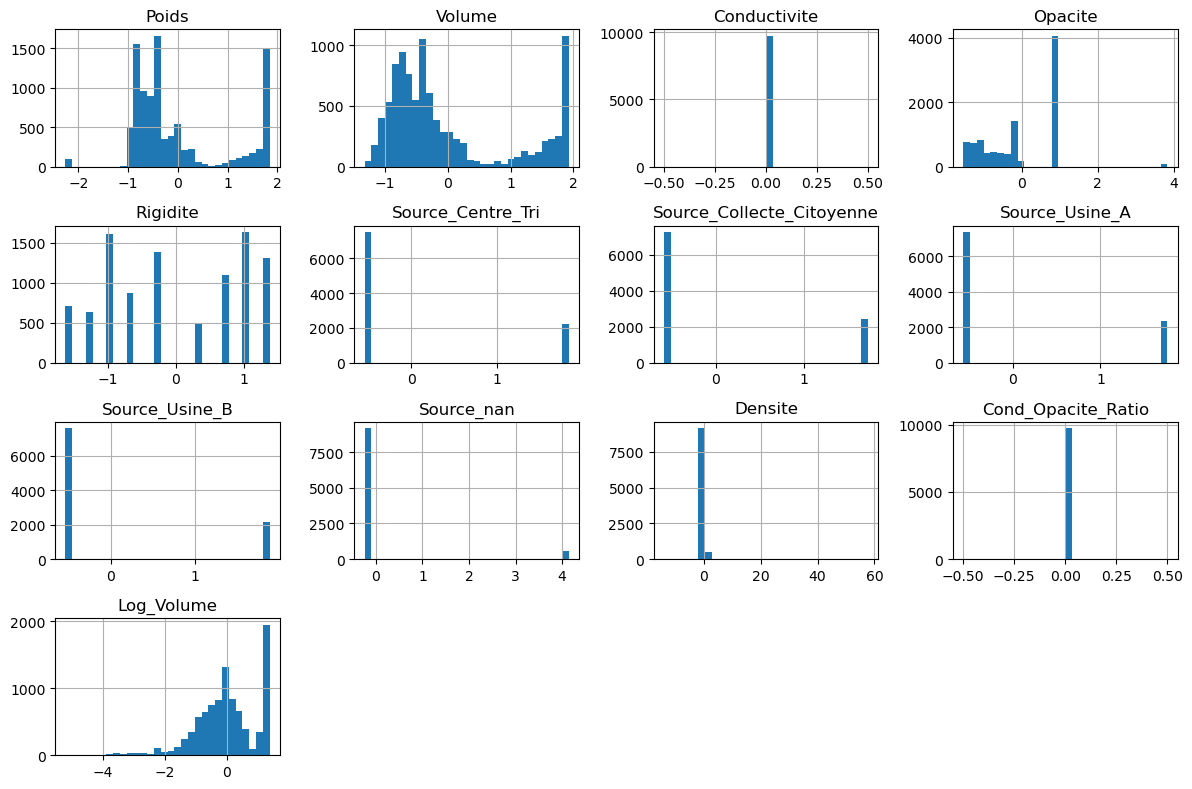

In [7]:
target_cols = [c for c in ["Categorie", "Prix_Revente"] if c in df_fe.columns]

numeric_cols_fe = df_fe.select_dtypes(include=["number"]).columns.tolist()
num_features = [c for c in numeric_cols_fe if c not in target_cols]

scaler = StandardScaler()

df_scaled = df_fe.copy()
df_scaled[num_features] = scaler.fit_transform(df_fe[num_features])

# Controle rapide des distributions
_ = df_scaled[num_features].hist(figsize=(12, 8), bins=30)
plt.tight_layout()


## 7. Separation train/test et sauvegarde des jeux prepares

Split 70/15/15 avec stratification sur `Categorie`, puis sauvegarde en CSV.


In [9]:
# Nettoyage final des NaN avant split (la stratification n'accepte pas de NaN)
if "Categorie" not in df_scaled.columns:
    raise ValueError("La colonne 'Categorie' est requise pour la stratification.")

na_report = df_scaled.isna().sum().sort_values(ascending=False)
print("NaN par colonne (top 10):")
print(na_report.head(10))

# Retirer les lignes sans label
before_rows = len(df_scaled)
df_scaled = df_scaled.dropna(subset=["Categorie"]).copy()
print("Lignes supprimees (Categorie NaN):", before_rows - len(df_scaled))

# Imputation simple des NaN numeriques restants (securite)
num_cols = df_scaled.select_dtypes(include=["number"]).columns
for col in num_cols:
    if df_scaled[col].isna().any():
        df_scaled[col] = df_scaled[col].fillna(df_scaled[col].median())

train_df, temp_df = train_test_split(
    df_scaled,
    test_size=0.30,
    stratify=df_scaled["Categorie"],
    random_state=RANDOM_STATE,
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["Categorie"],
    random_state=RANDOM_STATE,
)

print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

train_df.to_csv(OUTPUT_DIR / "train_clean.csv", index=False)
val_df.to_csv(OUTPUT_DIR / "val_clean.csv", index=False)
test_df.to_csv(OUTPUT_DIR / "test_clean.csv", index=False)

df_scaled.to_csv(OUTPUT_DIR / "dataset_clean_full.csv", index=False)


NaN par colonne (top 10):
Prix_Revente         533
Categorie            511
Log_Volume           211
Poids                  0
Volume                 0
Conductivite           0
Opacite                0
Rigidite               0
Rapport_Collecte       0
Source_Centre_Tri      0
dtype: int64
Lignes supprimees (Categorie NaN): 511
Train: (6449, 16)
Val: (1382, 16)
Test: (1382, 16)
